# Implémentation de l'algorithme MA-POCA sur ICE Hockey

## Chargement du jeu

In [1]:
import supersuit as ss
import gymnasium as gym
from pettingzoo.atari import ice_hockey_v2

def target_env():
    env = ice_hockey_v2.env()
    env = ss.color_reduction_v0(env, mode='grey')
    env.reset()
    env = ss.resize(env, x_size=84, y_size=84)
    env = ss.frame_stack_v1(env, 4)
    return env

## Réseau de neurones pour l'encodage des observations

In [1]:
from observation_encoding import Residual_block
from observation_encoding import Impala_Layer
from observation_encoding import Impala_CNN
import torch

def sanity_check_impala():
    #paramètres
    batch_size = 8
    input_shape = (4, 84, 84) # 4 frames stacked, 84x84 pixels
    feature_dim = 512

    #initialisation du modèle

    impala_model = Impala_CNN(input_shape=input_shape, feature_dim=feature_dim)

    # Création d'un batch de tests

    sample_input = torch.randn(batch_size, *input_shape)  # (batch_size, channels, height, width)

    print(f"--- Sanity Check Impala CNN ---")
    print(f"Entrée du batch : {sample_input.shape}") # [8, 4, 84, 84]

    #Propagation avant

    try:
        with torch.no_grad():
            output = impala_model(sample_input)

        print(f"Sortie du batch : {output.shape}") # [8, 512]

        assert output.shape == (batch_size, feature_dim), f"Expected output shape {(batch_size, feature_dim)}, but got {output.shape}"
        assert not torch.isnan(output).any(), "Output contains NaN values"

        print("Résultat du sanity check : SUCCESS")
    
    except Exception as e:
        print(f"Résultat du sanity check : FAILURE - {str(e)}")


In [2]:
sanity_check_impala()

--- Sanity Check Impala CNN ---
Entrée du batch : torch.Size([8, 4, 84, 84])
Sortie du batch : torch.Size([8, 512])
Résultat du sanity check : SUCCESS


Test de validité du gradient

In [8]:
def check_gradient_flow(impala_model):

    batch_size = 8
    x = torch.randn(batch_size, 4, 84, 84)
    target = torch.randn(batch_size, 512) #sortie attendue

    # propagation avant + loss

    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(impala_model.parameters(), lr=1e-4)

    output = impala_model(x)
    loss = criterion(output, target)

    # propagation arrière

    optimizer.zero_grad()
    loss.backward()

    # vérification des gradients

    has_grad = True
    for name, param in impala_model.named_parameters():
        if param.grad is None:
            print(f"Paramètre {name} n'a pas de gradient.")
            has_grad = False
        elif torch.all(param.grad == 0):
            print(f"⚠️ Gradient nul pour {name}")
            has_grad = False
    
    if has_grad:
        print("✅ Flux de gradient détecté sur tous les paramètres.")

    old_weights = impala_model.layer1.conv.weight.clone()
    optimizer.step()
    new_weights = impala_model.layer1.conv.weight.clone()

    if not torch.equal(old_weights, new_weights):
        print("✅ Les poids ont été mis à jour après l'optimizer.step().")


Affichage des courbes d'apprentissage et de loss

In [20]:
import matplotlib.pyplot as plt

def plot_training_curves(impala_model, num_epoch=50):
    optimizer = torch.optim.Adam(impala_model.parameters(), lr=1e-4)
    criterion = torch.nn.MSELoss()

    # données fixes pour forcer le surapprentissage

    x_train = torch.randint(0, 256, (16, 4, 84, 84)).float() # (batch_size, channels, height, width)
    y_train = torch.randn(16, 512) # (batch_size, feature_dim)

    x_val = torch.randint(0, 256, (8, 4, 84, 84)).float()
    y_val = torch.randn(8, 512)

    train_history = []
    val_history = []

    print("Début du test d'overfitting...")

    for epoch in range(num_epoch):

        # Entraînement
        impala_model.train()
        optimizer.zero_grad()
        output = impala_model(x_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()
        train_history.append(loss.item())

        # Evaluation

        impala_model.eval()
        with torch.no_grad():
            val_output = impala_model(x_val)
            val_loss = criterion(val_output, y_val)
            val_history.append(val_loss.item())
        
        if epoch % 20 == 0:
            print(f"Époque {epoch}: Train Loss {loss.item():.4f} | Val Loss {val_loss.item():.4f}")
    
    # Affichage des courbes

    plt.figure(figsize=(10, 5))
    plt.plot(train_history, label='Train Loss (Overfitting Target)')
    plt.plot(val_history, label='Validation Loss (Generalization Test)', linestyle='--')
    plt.yscale('log')
    plt.xlabel('Époques')
    plt.ylabel('MSE Loss')
    plt.title('Sanity Check : Capacité d\'apprentissage vs Généralisation')
    plt.legend()
    plt.grid(True)
    plt.show()


✅ Flux de gradient détecté sur tous les paramètres.
✅ Les poids ont été mis à jour après l'optimizer.step().
Début du test d'overfitting...
Époque 0: Train Loss 0.9836 | Val Loss 1.0191
Époque 20: Train Loss 0.9528 | Val Loss 1.0335
Époque 40: Train Loss 0.9444 | Val Loss 1.0356


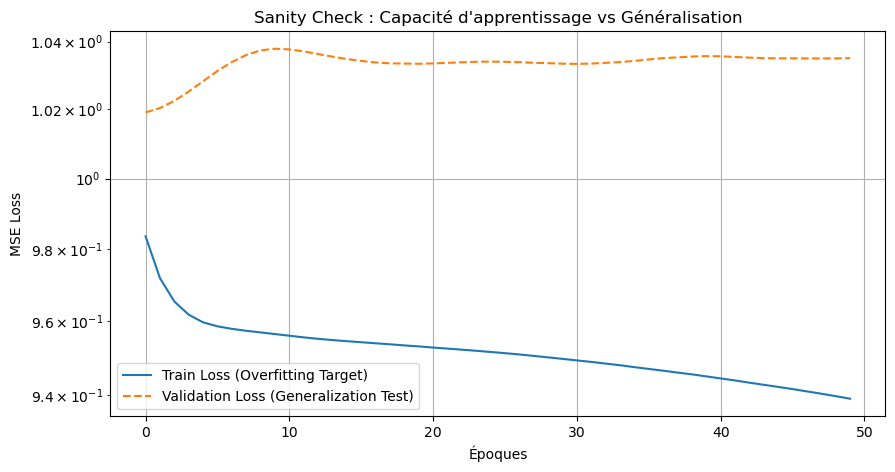

In [21]:
impala_model = Impala_CNN(input_shape=(4, 84, 84), feature_dim=512)
check_gradient_flow(impala_model)
plot_training_curves(impala_model, num_epoch=50)

on a bien de l'overfitting sur notre petit batch de données, les poids sont bien mis à jours après chaque itération. Donc notre Impala CNN fonctionne

## Implémentation du module Residual-Self-Attention 

In [22]:
from RSA import RSAModule

def sanity_check_rsa():
    batch_size = 8
    num_agents = 2
    feature_dim = 512

    rsa = RSAModule(feature_dim=feature_dim, num_heads=4)

    # on simule la sortie de 2 Impala_CNN pour 2 agents

    simulated_features = torch.randn(batch_size, num_agents, feature_dim) # (batch_size, num_agents, feature_dim)

    output = rsa(simulated_features)

    print(f"Entrée RSA (Agents empilés) : {simulated_features.shape}")
    print(f"Sortie RSA : {output.shape}")

    assert output.shape == (batch_size, num_agents, feature_dim)
    print("✅ Le module RSA traite correctement les interactions entre agents.")


In [23]:
sanity_check_rsa()

Entrée RSA (Agents empilés) : torch.Size([8, 2, 512])
Sortie RSA : torch.Size([8, 2, 512])
✅ Le module RSA traite correctement les interactions entre agents.
